Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [24]:
df = pd.read_csv("/content/student_performance_dataset.csv")

Data Exploration

In [25]:
print(df.head())
print(df.info())
print(df.isnull().sum())

  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                         No   
4                  Masters                      No                        Yes   

   Final_Exam_Score Pass_F

Remove Duplicates


In [26]:
df.drop_duplicates(inplace=True)

Remove Student ID

In [27]:
if 'Student_ID' in df.columns:
    df.drop('Student_ID', axis=1, inplace=True)

Encoding Categorical Columns

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Parental_Education_Level',
    'Internet_Access_at_Home',
    'Extracurricular_Activities',
    'Pass_Fail'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

Descriptive Statistics

In [29]:
print("\nAverage Study Hours:",
      df['Study_Hours_per_Week'].mean())

print("Average Attendance:",
      df['Attendance_Rate'].mean())

print("Average Past Exam Score:",
      df['Past_Exam_Scores'].mean())

print("Average Final Exam Score:",
      df['Final_Exam_Score'].mean())


Average Study Hours: 25.184
Average Attendance: 75.83068883324734
Average Past Exam Score: 75.218
Average Final Exam Score: 56.378


Visualization

 Pass vs Fail

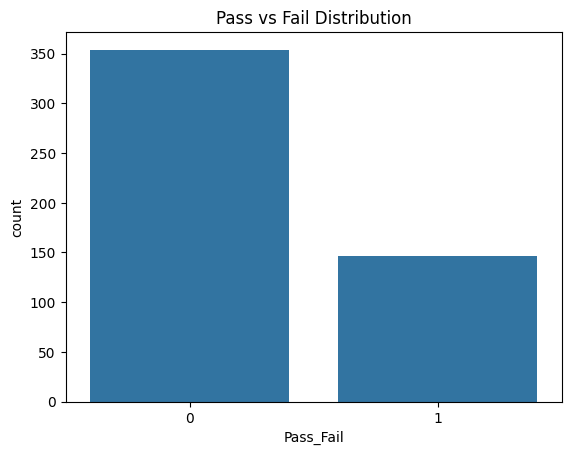

In [30]:
sns.countplot(x='Pass_Fail', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

Gender Distribution

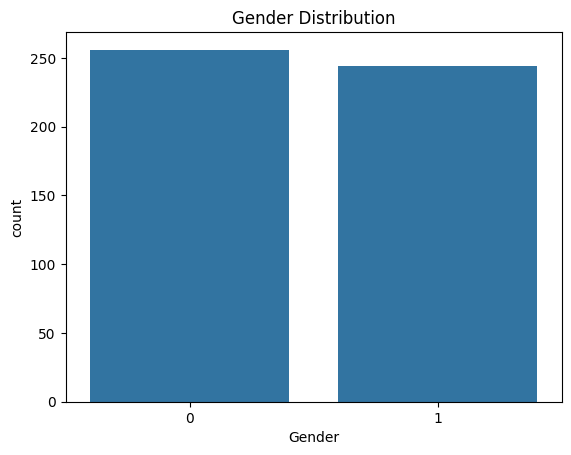

In [31]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

Study Hours Histogram

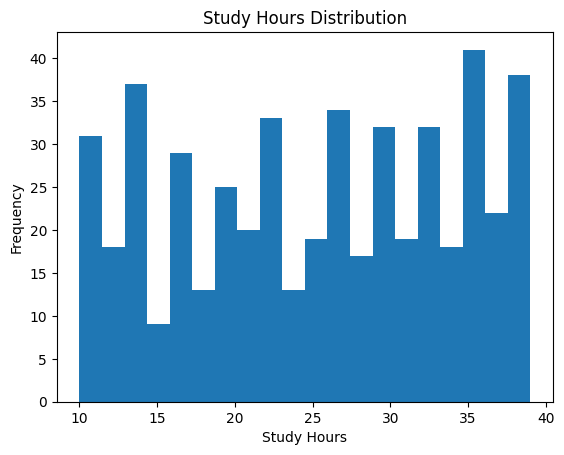

In [32]:
plt.hist(df['Study_Hours_per_Week'], bins=20)
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

Attendance Histogram

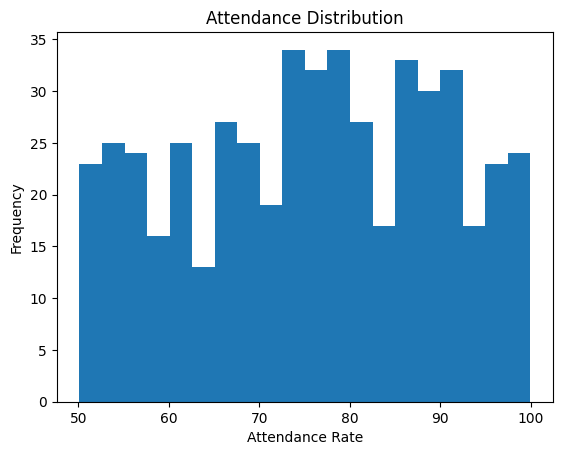

In [33]:
plt.hist(df['Attendance_Rate'], bins=20)
plt.title("Attendance Distribution")
plt.xlabel("Attendance Rate")
plt.ylabel("Frequency")
plt.show()

Final Exam Score Histogram

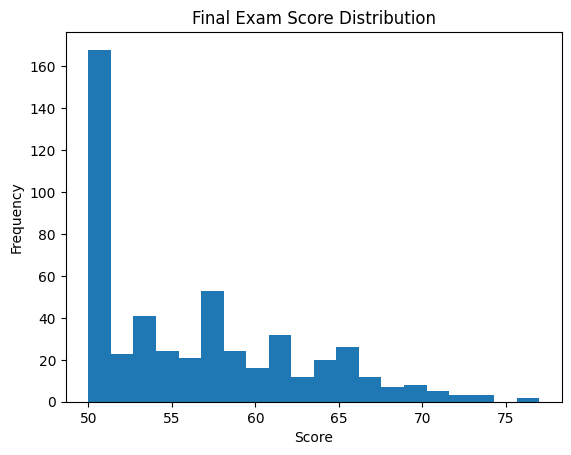

In [34]:
plt.hist(df['Final_Exam_Score'], bins=20)
plt.title("Final Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

Study Hours vs Final Score

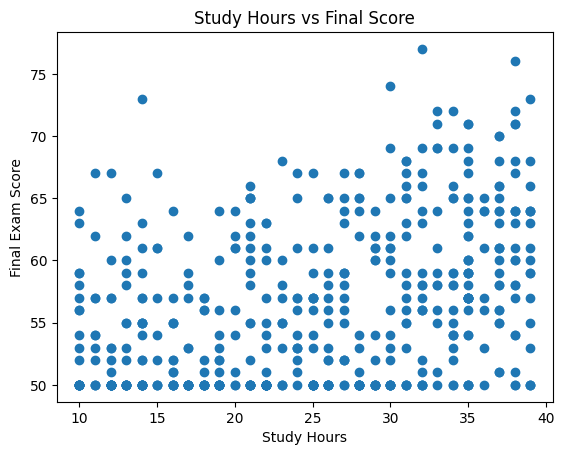

In [35]:
plt.scatter(
    df['Study_Hours_per_Week'],
    df['Final_Exam_Score']
)
plt.xlabel("Study Hours")
plt.ylabel("Final Exam Score")
plt.title("Study Hours vs Final Score")
plt.show()

Attendance vs Final Score

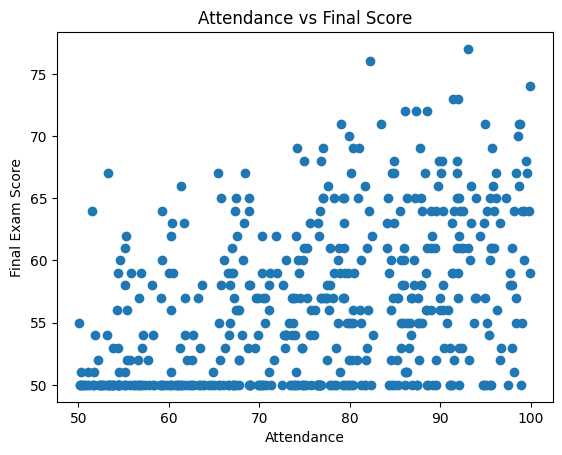

In [36]:
plt.scatter(
    df['Attendance_Rate'],
    df['Final_Exam_Score']
)
plt.xlabel("Attendance")
plt.ylabel("Final Exam Score")
plt.title("Attendance vs Final Score")
plt.show()

Box Plot

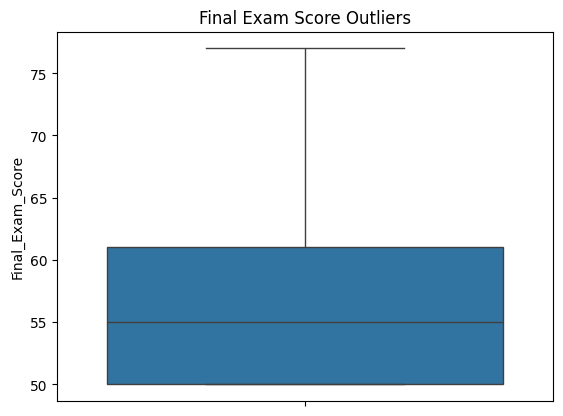

In [37]:
sns.boxplot(y=df['Final_Exam_Score'])
plt.title("Final Exam Score Outliers")
plt.show()

Correlation Heatmap

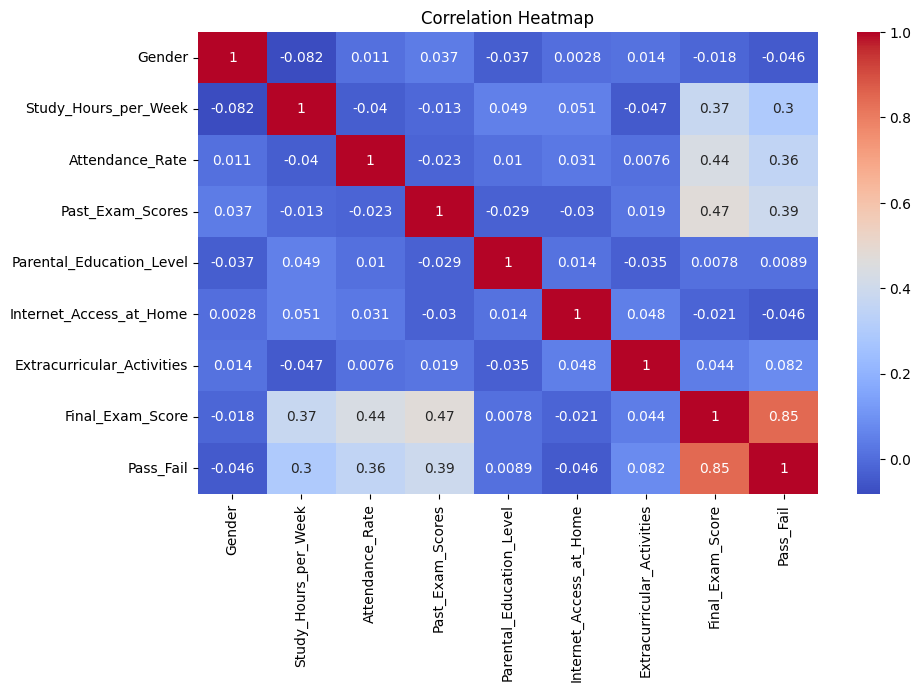

In [38]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Risk Analysis

In [39]:
def risk_category(row):

    if (row['Attendance_Rate'] < 60 and
        row['Study_Hours_per_Week'] < 10 and
        row['Past_Exam_Scores'] < 50):
        return "High Risk"

    elif (row['Attendance_Rate'] < 75):
        return "Medium Risk"

    else:
        return "Low Risk"

df['Risk_Category'] = df.apply(
    risk_category,
    axis=1
)

print(df['Risk_Category'].value_counts())

Risk_Category
Low Risk       269
Medium Risk    231
Name: count, dtype: int64


Logistic Regression

In [40]:
X = df.drop(
    ['Pass_Fail','Risk_Category'],
    axis=1
)

y = df['Pass_Fail']

Train Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model Training

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Prediction



In [47]:
y_pred = model.predict(X_test)

Evaluation

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred
))

print("\nConfusion Matrix")
print(confusion_matrix(
    y_test,
    y_pred
))


Accuracy: 0.99

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        75
           1       1.00      0.96      0.98        25

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100


Confusion Matrix
[[75  0]
 [ 1 24]]


ROC-AUC

In [51]:
from sklearn.metrics import roc_auc_score

prob = model.predict_proba(X_test)[:,1]

print(
    "\nROC AUC Score:",
    roc_auc_score(y_test, prob)
)

print("\nModel Training Completed Successfully!")


ROC AUC Score: 1.0

Model Training Completed Successfully!
